<a href="https://colab.research.google.com/github/Nam19ti/ML/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd

In [14]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [15]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1255,ham,Just wait till end of march when el nino gets ...,NaN,NaN,NaN
472,ham,Nothing. I meant that once the money enters yo...,NaN,NaN,NaN
2400,ham,Hi! This is Roger from CL. How are you?,NaN,NaN,NaN
3518,ham,Hanging out with my brother and his family,NaN,NaN,NaN
808,ham,I am taking half day leave bec i am not well,NaN,NaN,NaN


In [16]:
df.shape

(5572, 5)

In [17]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [19]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [20]:
df.sample(5)

,v1,v2
1829,spam,Hottest pics straight to your phone!! See me g...
4987,ham,Which channel:-):-):):-).
4308,ham,He dint tell anything. He is angry on me that ...
620,ham,Dear we got &lt;#&gt; dollars hi hi
4880,ham,When/where do I pick you up


In [21]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1396,ham,Shall i start from hear.
4763,ham,Hi.:)technical support.providing assistance to...
3939,ham,Does daddy have a bb now.
3158,ham,Are you up for the challenge? I know i am :)
3730,ham,Isn't frnd a necesity in life? imagine urself ...


In [22]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [23]:
df['target'] = encoder.fit_transform(df['target'])

In [24]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
# missing values
df.isnull().sum()

,0
target,0
text,0


In [26]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [27]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.shape

(5169, 2)

## 2.EDA

In [30]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
df['target'].value_counts()

,count
target,
0,4516
1,653


#Tỷ lệ giữa tin nhắn thường (ham) và tin nhắn rác (spam)

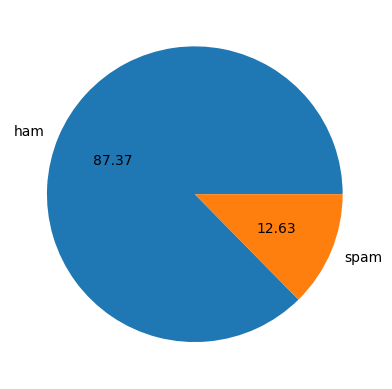

In [32]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

Dữ liệu bị mất cân bằng (imbalanced data): khoảng 87.37% là tin thường và 12.63% là spam -> thông tin quan trọng để lưu ý khi chọn chỉ số đánh giá mô hình sau này

In [33]:
import nltk  # Thư viện xử lý ngôn ngữ tự nhiên
nltk.download('punkt') # Tải bộ tách từ và câu
nltk.download('punkt_tab') # Tải dữ liệu bổ sung cho punkt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
df['num_characters'] = df['text'].apply(len)
#Tạo cột mới num_characters chứa số ký tự của mỗi tin nhắn/email trong cột text.

In [35]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [36]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
# Tạo cột num_words chứa số từ trong mỗi tin nhắn/email.

In [37]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [38]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
# Tạo cột num_sentences chứa số câu trong mỗi tin nhắn/email.

In [39]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [40]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [41]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [42]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Một tin nhắn spam có thể chứa số lượng ký tự, số từ và số câu trung bình cao hơn nhiều so với tin nhắn thông thường

In [43]:
import seaborn as sns

#Biểu đồ phân phối của độ dài ký tự giữa hai nhóm ham và spam

<Axes: xlabel='num_characters', ylabel='Count'>

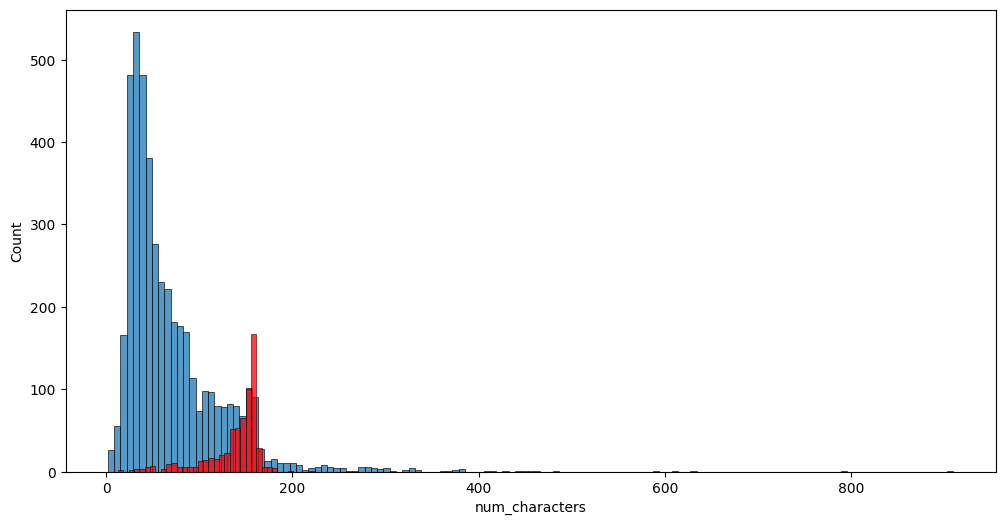

In [44]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

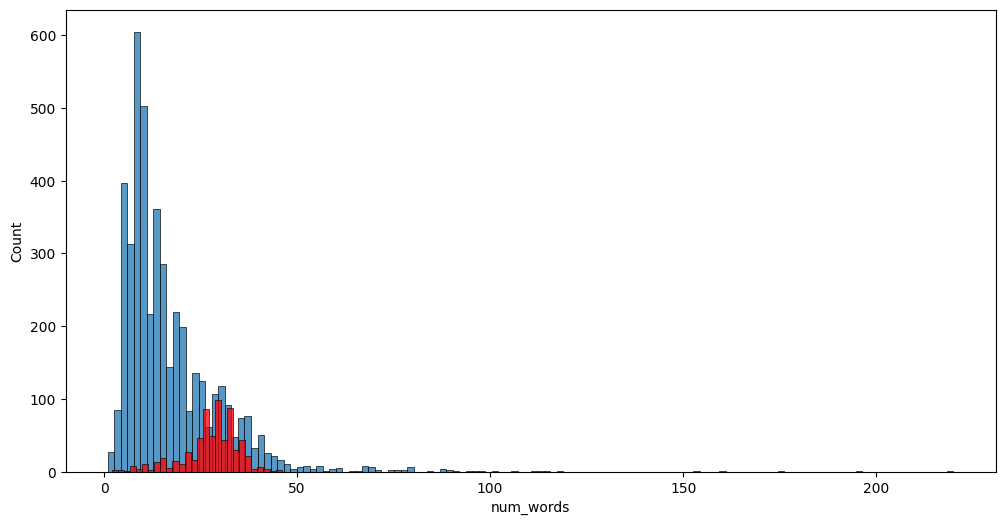

In [45]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

 # Mối quan hệ giữa các biến

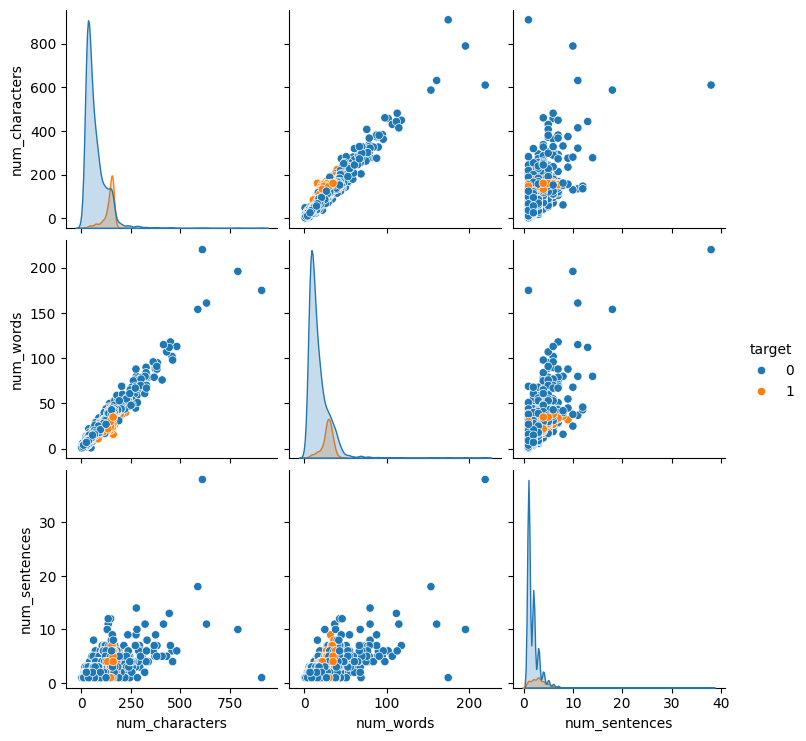

In [46]:
sns.pairplot(df,hue='target')

<Axes: >

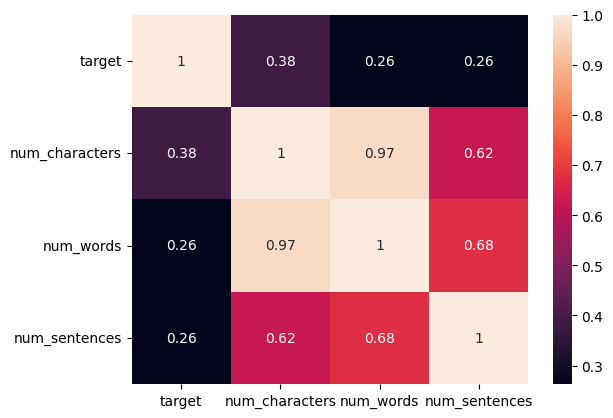

In [47]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

- 3 đặc trưng mới (num_characters, num_words, num_sentences) đều có tương quan dương với biến target (1 là spam) -> các chỉ số này tăng lên, khả năng tin nhắn đó là spam cũng tăng theo
- num_characters và num_words có hệ số tương quan lên tới 0.97 -> chứa nhiều thông tin tương đồng nhau.
- chọn cột num_characters làm đại diện chính vì nó có hệ số tương quan tốt nhất với biến mục tiêu (0.38) so với các cột còn lại

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [48]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem.porter import PorterStemmer
def transform_text(text):
    text = text.lower() #Chuyển về chữ thường
    text = nltk.word_tokenize(text) #Tách từ

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ dấu câu và ký tự đặc biệt, chỉ giữ chữ và số
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ các từ ít ý nghĩa như: a, an, the, is, of,...
    for i in text:
        y.append(ps.stem(i))
#đưa từ về dạng nguyên thể

    return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [49]:
ps = PorterStemmer()
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [50]:
df['transformed_text'] = df['text'].apply(transform_text)

In [51]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [52]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [53]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Spam

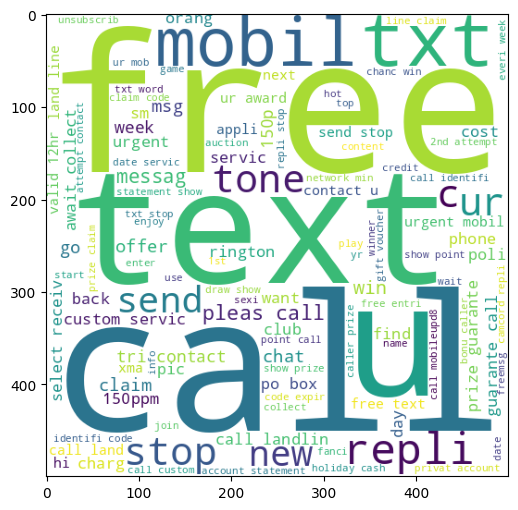

In [54]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

Tin nhắn spam thường chứa các từ khóa đặc trưng nhằm mục đích lôi kéo người dùng như: "call", "free", "offer", "prize", "text", "urgent"

In [55]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Ham

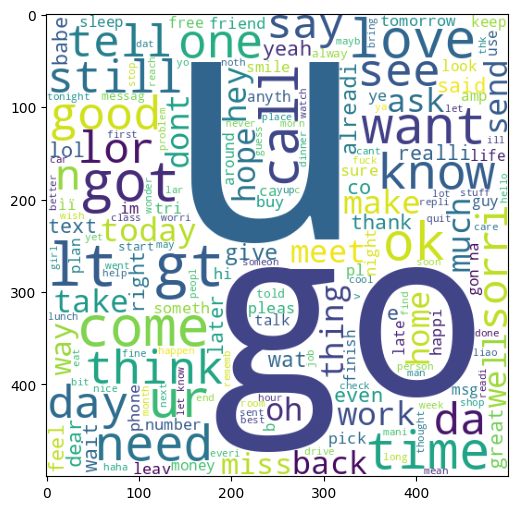

In [56]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

Tin nhắn thường, các từ xuất hiện phổ biến hơn mang tính giao tiếp đời thường như: "go", "come", "got", "love",...

In [57]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [58]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn spam
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [59]:
len(spam_corpus)

9939

# Các từ xuất hiện nhiều nhất trong tin nhắn spam

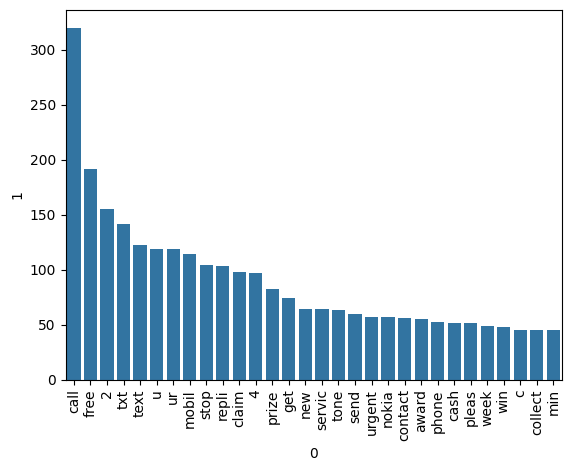

In [60]:
from collections import Counter

df_temp = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(
    x=df_temp[0],
    y=df_temp[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [61]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn ham
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [62]:
len(ham_corpus)

35404

# Các từ xuất hiện nhiều nhất trong tin nhắn ham

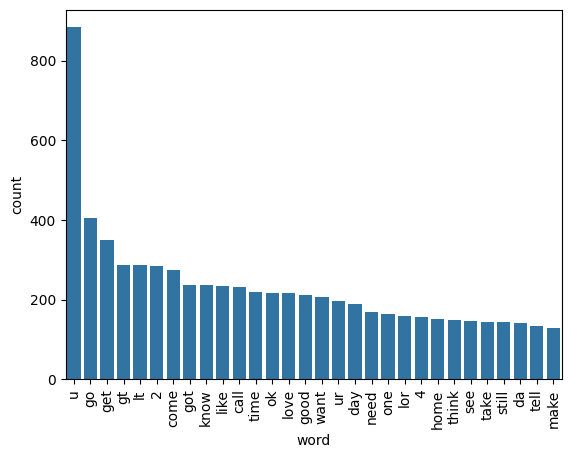

In [63]:
from collections import Counter

ham_df = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(
    data=ham_df,
    x='word',
    y='count'
)

plt.xticks(rotation=90)
plt.show()

In [64]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [65]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

Công thức TF-IDF

- TF-IDF(t,d)=TF(t,d)×IDF(t)

Trong đó:

- TF (Term Frequency): số lần từ xuất hiện trong văn bản.
- IDF (Inverse Document Frequency): mức độ hiếm của từ trong toàn bộ tập dữ liệu.

TF-IDF không chỉ đếm số lần xuất hiện của từ mà còn đánh giá mức độ quan trọng của từ trong toàn bộ tập dữ liệu. Điều này giúp mô hình tập trung vào các từ đặc trưng của email spam và thường cho kết quả tốt hơn Bag of Words.

In [66]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [67]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [68]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [69]:
X.shape

(5169, 3000)

In [70]:
y = df['target'].values

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [76]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,fbeta_score

In [78]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [79]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(fbeta_score(y_test, y_pred1, beta=0.5))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182
0.5599214145383105


Dữ liệu bị mất cân bằng (imbalanced data), nên Accuracy (độ chính xác) không phải là thước đo đáng tin cậy nhất.
Tác giả tập trung vào chỉ số Precision (Độ chính xác của việc dự báo spam)
- Mục tiêu là tối đa hóa Precision để tránh việc tin nhắn bình thường (ham) bị hệ thống nhầm lẫn đánh dấu là spam (giảm thiểu False Positives).

In [80]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(fbeta_score(y_test, y_pred2, beta=0.5))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0
0.9473684210526315


In [81]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
print(fbeta_score(y_test, y_pred3, beta=0.5))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187
0.9682539682539683


In [82]:
# tfidf --> MNB

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [84]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [85]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [86]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

### Fβ-Score Explained

The Fβ-Score is the weighted harmonic mean of precision and recall, reaching its best value at 1 and worst at 0.

*   `β` is a parameter that determines the weight of recall in the combined score.
    *   If `β = 1` (F1-Score), precision and recall are equally important.
    *   If `β < 1` (e.g., F0.5-Score), precision is weighted more heavily than recall. This is useful when false positives are more costly than false negatives, aligning with your goal of minimizing ham classified as spam.
    *   If `β > 1` (e.g., F2-Score), recall is weighted more heavily than precision. This is useful when false negatives are more costly than false positives (e.g., not detecting a spam message).

Given your focus on minimizing false positives (ham classified as spam), let's calculate the F0.5-Score, which gives more weight to precision.

In [87]:
from sklearn.metrics import fbeta_score

def train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    # Calculate F0.5-score, giving more weight to precision
    f0_5_score = fbeta_score(y_test, y_pred, beta=0.5)

    return accuracy, precision, f0_5_score

In [88]:
accuracy_scores_fbeta = []
precision_scores_fbeta = []
f0_5_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision, current_f0_5_score = train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test)

    print(f"For {name}")
    print(f"Accuracy - {current_accuracy}")
    print(f"Precision - {current_precision}")
    print(f"F0.5-Score - {current_f0_5_score}")
    print("\n")

    accuracy_scores_fbeta.append(current_accuracy)
    precision_scores_fbeta.append(current_precision)
    f0_5_scores.append(current_f0_5_score)

For SVC
Accuracy - 0.9758220502901354
Precision - 0.9747899159663865
F0.5-Score - 0.9446254071661238


For KN
Accuracy - 0.9052224371373307
Precision - 1.0
F0.5-Score - 0.6711409395973155


For NB
Accuracy - 0.9709864603481625
Precision - 1.0
F0.5-Score - 0.9473684210526315


For DT
Accuracy - 0.9323017408123792
Precision - 0.8333333333333334
F0.5-Score - 0.7783882783882784


For LR
Accuracy - 0.9555125725338491
Precision - 0.96
F0.5-Score - 0.8921933085501859


For RF
Accuracy - 0.9738878143133463
Precision - 0.9826086956521739
F0.5-Score - 0.9448160535117057


For AdaBoost
Accuracy - 0.9216634429400387
Precision - 0.8202247191011236
F0.5-Score - 0.7388663967611336


For BgC
Accuracy - 0.9584139264990329
Precision - 0.8682170542635659
F0.5-Score - 0.8562691131498471


For ETC
Accuracy - 0.9748549323017408
Precision - 0.9745762711864406
F0.5-Score - 0.9426229508196722


For GBDT
Accuracy - 0.9506769825918762
Precision - 0.9306930693069307
F0.5-Score - 0.8671586715867159


For xgb
Accur

In [89]:
performance_df_fbeta = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores_fbeta,
    'Precision': precision_scores_fbeta,
    'F0.5_Score': f0_5_scores
}).sort_values('F0.5_Score', ascending=False)

display(performance_df_fbeta)

,Algorithm,Accuracy,Precision,F0.5_Score
2,NB,0.970986,1.000000,0.947368
5,RF,0.973888,0.982609,0.944816
0,SVC,0.975822,0.974790,0.944625
8,ETC,0.974855,0.974576,0.942623
10,xgb,0.968085,0.948718,0.915842
4,LR,0.955513,0.960000,0.892193
9,GBDT,0.950677,0.930693,0.867159
7,BgC,0.958414,0.868217,0.856269
3,DT,0.932302,0.833333,0.778388
6,AdaBoost,0.921663,0.820225,0.738866


This new table, sorted by F0.5-Score, gives us a different perspective. Algorithms with high precision but potentially lower recall (which is desired to minimize false positives) will now be ranked higher if their F0.5-Score reflects that balance effectively.

In [90]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [91]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9323017408123792
Precision -  0.8333333333333334
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [92]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [93]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.932302,0.833333


In [94]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [95]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.932302


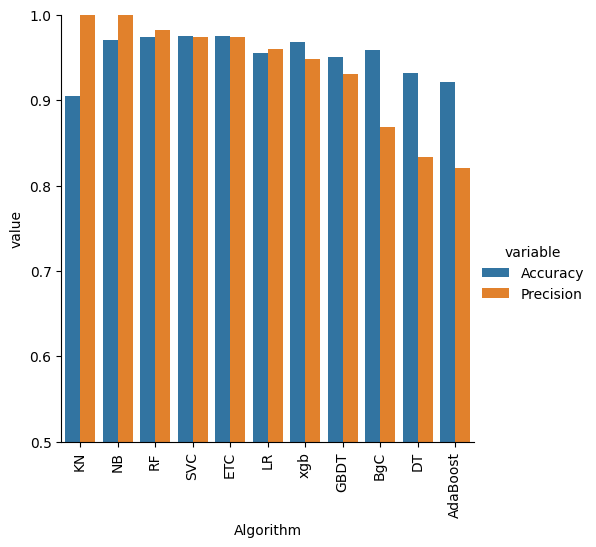

In [96]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [97]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [98]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [99]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [100]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [101]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [102]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [103]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
6,xgb,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
7,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,DT,0.932302,0.833333,0.932302,0.833333,0.932302,0.833333,0.932302,0.833333


In [104]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [105]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [106]:
voting.fit(X_train,y_train)
y_pred = voting.predict(X_test)

In [107]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [108]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [109]:
from sklearn.ensemble import StackingClassifier

In [110]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [111]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9787234042553191
Precision 0.9393939393939394
